# Analyse & Nettoyage — Books to Scrape

Ce notebook charge les CSV extraits par le scraper, nettoie les champs (prix, notes, stock), calcule des statistiques descriptives et produit quelques visualisations avec `seaborn`/`matplotlib` et `plotly`.

Remarques: placez vos CSVs dans `outputs/csv/` (format attendu: `category_<slug>.csv`).

In [17]:
# Imports et configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path
import glob
from IPython.display import display, Image

sns.set(style="whitegrid")
pd.options.display.max_columns = 60
%matplotlib inline

In [18]:
# Chargement de tous les CSVs de `outputs/csv`
csv_dir = Path('outputs/csv')
files = sorted(csv_dir.glob('category_*.csv'))
print(f'Found {len(files)} CSV files in {csv_dir}')
if not files:
    print('Aucun fichier CSV trouvé dans', csv_dir)
dfs = []
for f in files:
    print('Reading', f.name)
    df_tmp = pd.read_csv(f)
    # Inférer la catégorie depuis le nom de fichier si nécessaire
    cat = f.stem.replace('category_','')
    if 'category' not in df_tmp.columns:
        df_tmp['category'] = cat
    else:
        # Normaliser si la colonne existe mais est vide
        df_tmp['category'] = df_tmp['category'].fillna(cat)
    print('  ->', df_tmp.shape[0], 'rows')
    dfs.append(df_tmp)
df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
# Nombre total de livres trouvés dans les CSVs (outputs/csv)
total_books = int(df.shape[0])
print('Combined shape:', df.shape)
print(f'Total books found: {total_books}')
# Afficher toutes les lignes (le nombre total de livres trouvés)
display(df.head(total_books))

Found 1 CSV files in outputs\csv
Reading category_travel.csv
  -> 11 rows
Combined shape: (11, 11)
Total books found: 11


,title,price,price_raw,stock,stock_raw,rating_word,rating,product_url,image_url,upc,category
0,It's Only the Himalayas,45.17,Â£45.17,19,In stock (19 available),Two,2,https://books.toscrape.com/catalogue/its-only-...,https://books.toscrape.com/media/cache/6d/41/6...,a22124811bfa8350,Travel
1,Full Moon over Noahâs Ark: An Odyssey to Mou...,49.43,Â£49.43,15,In stock (15 available),Four,4,https://books.toscrape.com/catalogue/full-moon...,https://books.toscrape.com/media/cache/fe/8a/f...,ce60436f52c5ee68,Travel
2,See America: A Celebration of Our National Par...,48.87,Â£48.87,14,In stock (14 available),Three,3,https://books.toscrape.com/catalogue/see-ameri...,https://books.toscrape.com/media/cache/c7/1a/c...,f9705c362f070608,Travel
3,Vagabonding: An Uncommon Guide to the Art of L...,36.94,Â£36.94,8,In stock (8 available),Two,2,https://books.toscrape.com/catalogue/vagabondi...,https://books.toscrape.com/media/cache/ca/30/c...,1809259a5a5f1d8d,Travel
4,Under the Tuscan Sun,37.33,Â£37.33,7,In stock (7 available),Three,3,https://books.toscrape.com/catalogue/under-the...,https://books.toscrape.com/media/cache/45/21/4...,a94350ee74deaa07,Travel
5,A Summer In Europe,44.34,Â£44.34,7,In stock (7 available),Two,2,https://books.toscrape.com/catalogue/a-summer-...,https://books.toscrape.com/media/cache/6c/e3/6...,cc1936a9f4e93477,Travel
6,The Great Railway Bazaar,30.54,Â£30.54,6,In stock (6 available),One,1,https://books.toscrape.com/catalogue/the-great...,https://books.toscrape.com/media/cache/d5/82/d...,48736df57e7bec9f,Travel
7,A Year in Provence (Provence #1),56.88,Â£56.88,6,In stock (6 available),Four,4,https://books.toscrape.com/catalogue/a-year-in...,https://books.toscrape.com/media/cache/8b/81/8...,9e60929f521fa280,Travel
8,The Road to Little Dribbling: Adventures of an...,23.21,Â£23.21,3,In stock (3 available),One,1,https://books.toscrape.com/catalogue/the-road-...,https://books.toscrape.com/media/cache/26/f5/2...,366a236aa1ea6f07,Travel
9,Neither Here nor There: Travels in Europe,38.95,Â£38.95,3,In stock (3 available),Three,3,https://books.toscrape.com/catalogue/neither-h...,https://books.toscrape.com/media/cache/c9/9a/c...,747cf7fca2ccdbd4,Travel


In [19]:
# Nettoyage des colonnes importantes (prix, rating, stock)
def parse_price(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    # retirer symboles monétaires et espaces
    s = s.replace('£','').replace('$','').replace(',','').strip()
    try:
        return float(s)
    except Exception:
        return np.nan

# Créer colonne price si seulement price_raw existe
if 'price' not in df.columns and 'price_raw' in df.columns:
    df['price'] = df['price_raw'].apply(parse_price)
elif 'price' in df.columns:
    df['price'] = df['price'].apply(parse_price)
else:
    df['price'] = np.nan

# Rating: utiliser 'rating' numérique ou mapper 'rating_word'
rating_map = {'One':1,'Two':2,'Three':3,'Four':4,'Five':5}
if 'rating' not in df.columns and 'rating_word' in df.columns:
    df['rating'] = df['rating_word'].map(rating_map)
else:
    # forcer numeric si existe
    if 'rating' in df.columns:
        df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Stock: forcer entier à partir de 'stock' ou 'stock_raw'
if 'stock' not in df.columns and 'stock_raw' in df.columns:
    # tenter d'extraire nombre entre parenthèses si présent
    df['stock'] = df['stock_raw'].str.extract(r'\((\d+)\s+available\)')[0]
    df['stock'] = pd.to_numeric(df['stock'], errors='coerce').fillna(0).astype(int)
else:
    if 'stock' in df.columns:
        df['stock'] = pd.to_numeric(df['stock'], errors='coerce').fillna(0).astype(int)


# Afficher toutes les lignes pour les colonnes-clés (selon total_books calculé précédemment)
display(df[['title','price','rating','stock','category']].head(total_books))

,title,price,rating,stock,category
0,It's Only the Himalayas,45.17,2,19,Travel
1,Full Moon over Noahâs Ark: An Odyssey to Mou...,49.43,4,15,Travel
2,See America: A Celebration of Our National Par...,48.87,3,14,Travel
3,Vagabonding: An Uncommon Guide to the Art of L...,36.94,2,8,Travel
4,Under the Tuscan Sun,37.33,3,7,Travel
5,A Summer In Europe,44.34,2,7,Travel
6,The Great Railway Bazaar,30.54,1,6,Travel
7,A Year in Provence (Provence #1),56.88,4,6,Travel
8,The Road to Little Dribbling: Adventures of an...,23.21,1,3,Travel
9,Neither Here nor There: Travels in Europe,38.95,3,3,Travel


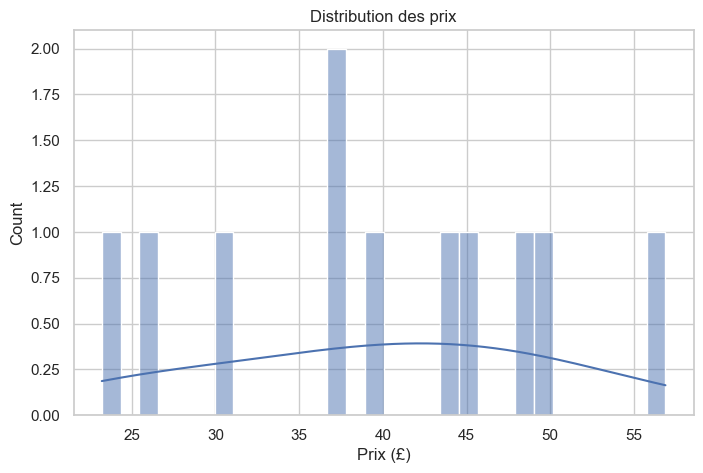

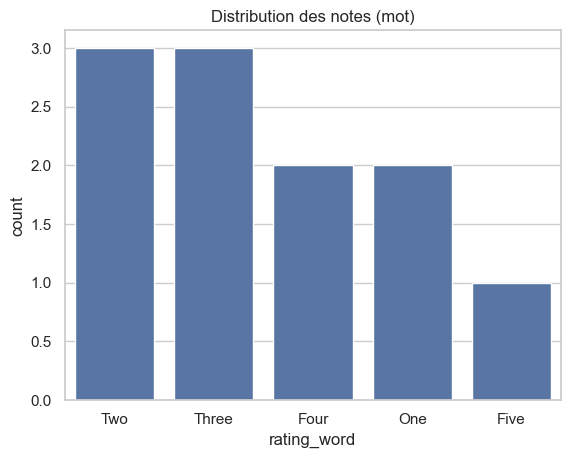

In [ ]:
# Visualisations simples

# Distribution des prix
plt.figure(figsize=(8,5))
sns.histplot(df['price'].dropna(), bins=30, kde=True, color='C0')
plt.title('Distribution des prix')
plt.xlabel('Prix (£)')
plt.show()


# Distribution des notes (mot)
order = df['rating_word'].value_counts().index if 'rating_word' in df.columns else None
sns.countplot(x='rating_word', data=df, order=order) if 'rating_word' in df.columns else None
plt.title('Distribution des notes (mot)')
plt.show()

In [19]:
# Visualisation interactive (Plotly) : Prix vs Note
if not df.empty:
    fig = px.strip(df, x='rating', y='price', color='category', hover_data=['title'], title='Prix vs Note')
    fig.update_traces(jitter=0.3)
    fig.show()